# 14.1. Nuclei Segmentation - Single FOV exploration

## Overview <br>

### **Motivation**: Count the number of nuclei on each FOV of interest. This count serves as a basic quantity metric for each FOV. By using DAPI - stained nuclei as spatial anchors, we can detect the exact coordinates of individual nuclei and count the total number of cells in the tissue. These nuclei coordinates serve as central anchors to map neighboring RNA spots to their respective cell IDs, transforming raw (x,y) transcript positions into a Cell x Gene expression matrix for the downtream analysis.<br>

### **Process**: Each FOV contain 4 DAPI images, one per sequencing cycle (C01 - C04). Initial testing using a single DAPI image (C01) showed the reasonable pineline for image processing and nuclei counting. To get more robust result, nuclei are segmented independently on each of the 4 DAPI images, and the final count is taken as the mean across 4 cycles. <br>

### **Image processing pineline**: Before counting number of nuclei, the DAPI image need to be applied preprocessing steps include filtering, thresholding, followed by  a morphological operation (to remove small noise) and a watershed algorithm (to separate connected nuclei into individual instance). The specific steps are outlined below.

# Nuclei segmentation on single DAPI image

## 1. **Load and inspect image**


In [2]:
# Import library

import glob
import os
import numpy as np
import pandas as pd
import skimage as ski
from skimage import io, filters
from skimage.filters import threshold_triangle, difference_of_gaussians
from skimage.morphology import disk, extrema
from skimage.measure import regionprops_table
from skimage.segmentation import watershed
from scipy import ndimage
from scipy.ndimage import distance_transform_edt
from skimage.color import label2rgb, gray2rgb
from skimage.segmentation import mark_boundaries
import matplotlib.pyplot as plt
from skimage.feature import peak_local_max

In [3]:
# Accessibility

PATH = '/Users/chann/Downloads/F1 Systems bio/Project/code/realistic_data/selected-tiles/'

Image processing workflow<br>
1. read image
2. filters - clean background
3. (histogram - threshold - binary image)/ automated histogram
4. watershed - refinement
5. ID - count - number

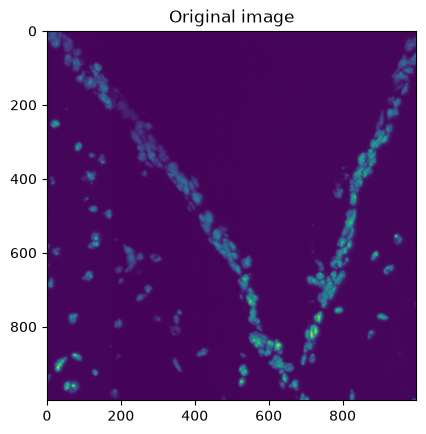

In [4]:
# Read image
path = '/Users/chann/Downloads/F1 Systems bio/Project/code/realistic_data/selected-tiles/out_opt_flow_registered_X10_Y2_c01_DAPI.tif'
im = io.imread(path).astype(np.float32) #
plt.imshow(im)
plt.title('Original image')#draw
plt.show()

Fluorescent images usually have noise => use gaussian filter

## 2. DAPI image preprocessing

### 2.0. Visualize by ImageJ <br>

This is the step used for visualizing data manually. By using ImageJ, the overall range of nuclei size can be estimated. From this evidence, we could filter nuclei by size in the last step.

### 2.1. Apply Gaussian filter

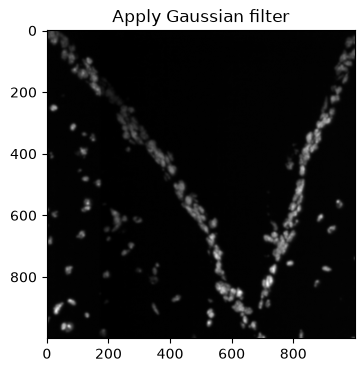

In [5]:
## Apply Gaussian filter
fig = plt.figure(figsize = (8,4)) #create figure

im_gauss = filters.gaussian(im, sigma = 2)
plt.imshow(im_gauss, cmap = 'gray')
plt.title('Apply Gaussian filter')
plt.show()

still have noise -> DOG filter

### 2.2. Apply background substraction

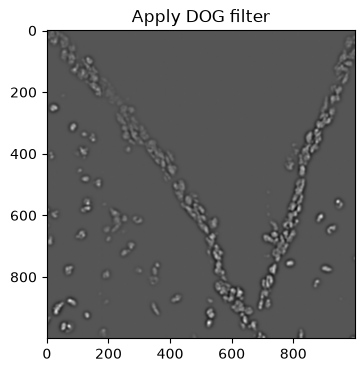

In [6]:
## Apply background substraction

fig3 = plt.figure(figsize = (8,4))
im_dog_1 = difference_of_gaussians(im,low_sigma = 3, high_sigma = 3*1.6)
plt.title('Apply DOG filter')
plt.imshow(im_dog_1, cmap = 'gray')
plt.show()

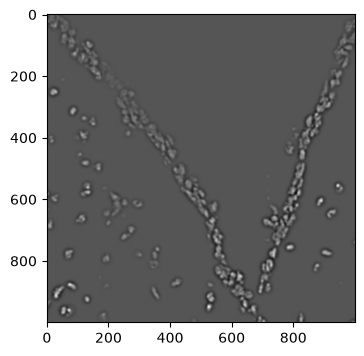

In [7]:
## Apply background substraction - Try to write function
fig4 = plt.figure(figsize = (8,4))

def result_difference_of_gaussians(im, sigma_lower, sigma_higher, clip_negative = True):
    im_dog_2 = difference_of_gaussians(im, low_sigma = sigma_lower, high_sigma = sigma_higher)
    return im_dog_2

im_dog_result = result_difference_of_gaussians(im, 3, 3*1.6)
plt.imshow(im_dog_result, cmap = 'gray') #pass image_show as argument to imshow
plt.show()

Image still has tiny noise => apply morphological opening after having binary image

### 2.3. Apply thresholding

#### **Show histogram**

-103.89664 205.59131 float32


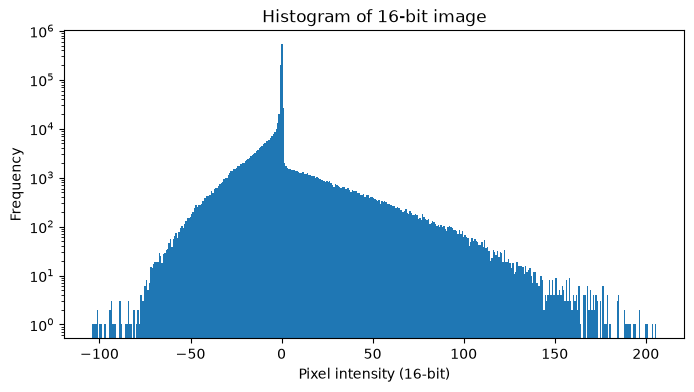

In [8]:
## Create binary image based on thresholding
## Show histogram
print(im_dog_result.min(), im_dog_result.max(), im_dog_result.dtype) #check min and max => check range of image

fig5 = plt.figure(figsize = (8,4))

plt.hist(im_dog_result.flatten(), bins= 400, range=(im_dog_result.min(), im_dog_result.max()), log = True)
plt.xlabel('Pixel intensity (16-bit)')
plt.ylabel('Frequency')
plt.title('Histogram of 16-bit image')
plt.show()

Misunderstanding: use original image to plot histogram and decide type of thresholding => should use gauss_image to plot histogram

right - skewed, unimodal histogram => Triangle threshold or self - choosing threshold<br>
Sharp spike at 0: most pixels are flat background, so the DoG (difference of two blurred images) is near 0. <br>
Gradual left slope: negative pixels, mostly the dark halo around bright objects. <br>
Sharp drop-> long right tail: the positive part, the cores of the bright objects ??!!!



#### **Apply manual thresholding**

<Figure size 800x400 with 0 Axes>

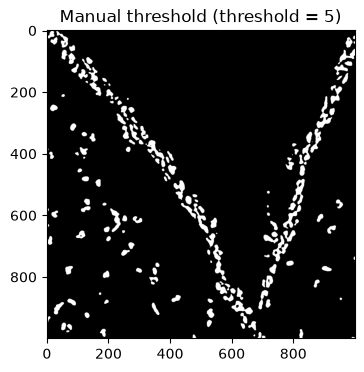

In [9]:
#set threshold
thresh = 5

#show result
fig6 = plt.figure(figsize = (8,4))
binary_image_manual = im_dog_result > thresh

plt.figure(figsize=(8, 4))
plt.imshow(binary_image_manual, cmap='gray')
plt.title(f'Manual threshold (threshold = {thresh})')
plt.show()

#### **Apply automated thresholding**

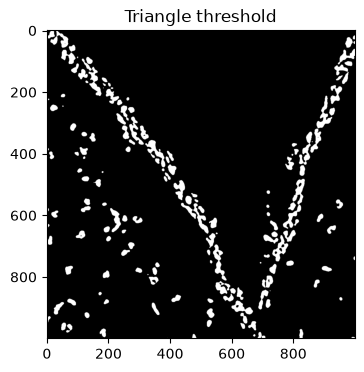

In [10]:
## Apply triangle threshold
binary_image_triangle = im_dog_result > threshold_triangle(im_dog_result)
plt.figure(figsize=(8, 4))
plt.title(f'Triangle threshold')
plt.imshow(binary_image_triangle, cmap='gray')

The result from automatic threshold and manula threshold are quite same. Still have tiny noise => need morphological opening<br>
The manual threshold setting applies only to the specific FOV you are viewing; if we switch to a different FOV with different brightness or gain settings, we must reconfigure each one individually. <br>
=> Automatic settings, however, apply the same rule to every image, ensuring reproducible results.

### 2.4. Apply morphological opening

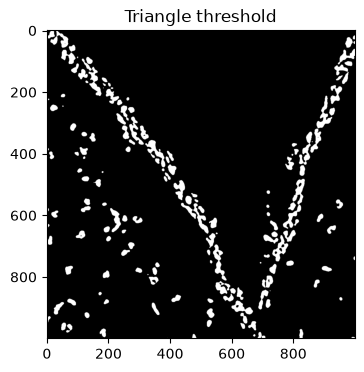

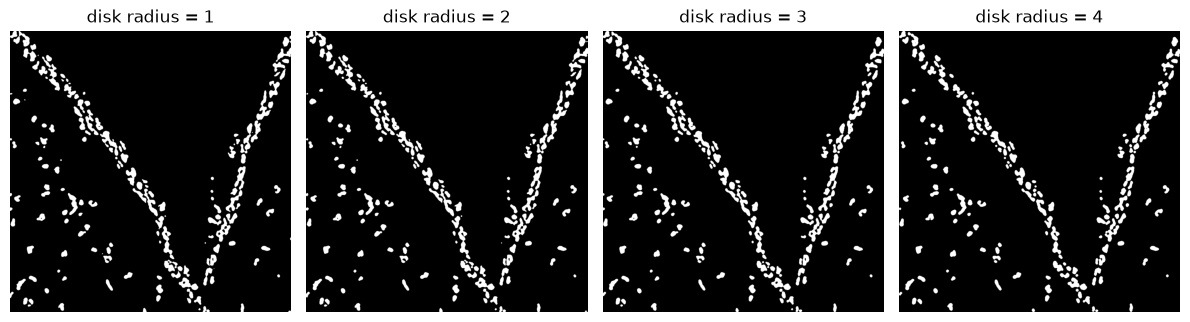

In [11]:
## Apply morphological opening - try with several disk values

radius_value = [1,2,3,4]
list_image_opened = []
def morphological_opening(binary_image, radius):
    image_opened = ndimage.binary_opening(binary_image, structure = ski.morphology.disk(radius))
    return image_opened

for r in radius_value:
    image_opened_list = morphological_opening(binary_image_triangle, r)
    list_image_opened.append(image_opened_list)

## Plotting
plt.figure(figsize=(8, 4))
plt.title(f'Triangle threshold')
plt.imshow(binary_image_triangle, cmap='gray')

fig, axes = plt.subplots(1,4, figsize = (12,8))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(list_image_opened[i], cmap='gray')
    ax.set_title(f'disk radius = {radius_value[i]}')
    ax.axis('off')
plt.tight_layout()
plt.show()

## Choose radius  = 4 for next step
image_opened = list_image_opened[3]


1. disk = [1,2] - too small to delete noise <br>
2. disk = 3 => much better but still contains noise on the left side => choose 4 <br>
3. problem: still have connected nuclei -> separate by watershed

### 2.5. Apply watershed algorithm

#### **Using peak local max**

Number of markers: 295


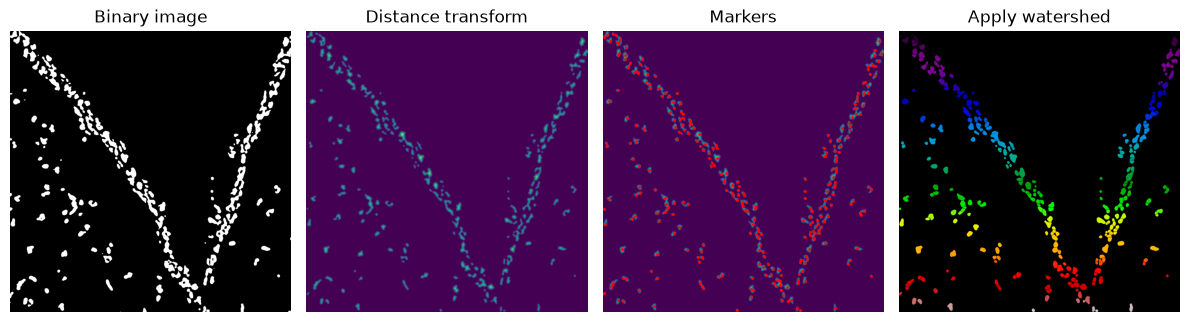

In [12]:
# Watershed using peak local max

## Distance transform
distance = ndimage.distance_transform_edt(image_opened) #syntax

## Find local maxima
coords = peak_local_max(distance, min_distance= 5, labels=image_opened)
mask = np.zeros(distance.shape, dtype=bool) #Ask claude
mask[tuple(coords.T)] = True #Ask claude
markers, num_markers = ndimage.label(mask)
print(f"Number of markers: {num_markers}")

## Watershed
image_watershed = watershed(-distance, markers=markers, mask=image_opened, watershed_line=True)

## Plotting
images = [binary_image_triangle, distance, distance, image_watershed]
cmaps = ['gray','viridis', 'viridis', 'nipy_spectral']
titles = ['Binary image', 'Distance transform', 'Markers', 'Apply watershed']

fig,axes = plt.subplots(1,4, figsize = (12,8))
for i, ax in enumerate(axes):
    ax.imshow(images[i], cmap = cmaps[i])
    ax.set_title(titles[i])
    ax.axis("off")

axes[2].plot(coords[:,1], coords[:,0],'r.', markersize =2)
plt.tight_layout()
plt.show()

1. Main target of doing manual watershed is to understand how progress works step by step. <br>
2. How to choose min_distance => calculate median size of spot -> min_distance must smaller than that. In this case the median is 6.xx => choose min_distance =4 or 5 <br>
2. syntax "r" in markersize => need to be "r." <br>
3. Remember to use enumerate when plotting(subplot) -> shorter. which case need flatten() or not? -> 1D array => no need flatten.

Number of object after watershed: 895


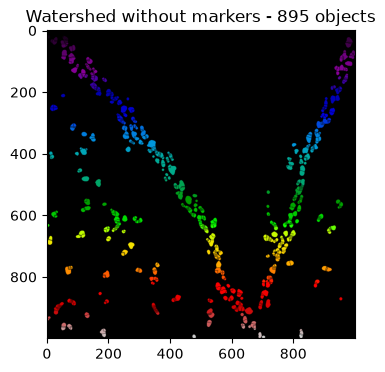

In [13]:
## watershed without markers
labels_automated = watershed(-distance, markers=None, mask=image_opened, watershed_line=True)
print(f"Number of object after watershed: {labels_automated.max()}")
plt.figure(figsize=(8,4))
plt.imshow(labels_automated, cmap='nipy_spectral')
plt.title(f'Watershed without markers - {labels_automated.max()} objects')
plt.show()

Add markers for watershed, because: without markers, the algorithm will automatically locate all local maxima in image (although they are noises) and treat them as real markers -> oversegmentation

#### **Using h_maxima**

In [14]:
## Watershed using h_maxima
image_dist = ndimage.distance_transform_edt(image_opened)
image_max = extrema.h_maxima(image_dist, 0.5)
image_max = ndimage.binary_dilation(image_max, structure=np.ones((3, 3)))
image_max = np.bitwise_and(image_opened, image_max)
image_label, n = ndimage.label(image_max)
image_watershed = watershed(-image_dist, markers=image_label, mask=image_opened, watershed_line=True)
image_cleaned = image_watershed > 0
number_nuclei = image_watershed.max()
print(n,number_nuclei)


270 270


Prefer to use automated watershed: <br>
- "h" - minimum depth of the neck in the distance map, depends less on the distance between the centers. <br>
- when use  min_distance => need to look at the size of nuclei -> decide -> longer time and bias

After applying watershed algorithmm, the connected nucleis can be separated. => distinguish them

### 2.6. Distinguish nuclei

Text(0.5, 1.0, 'Distinguish nuclei ')

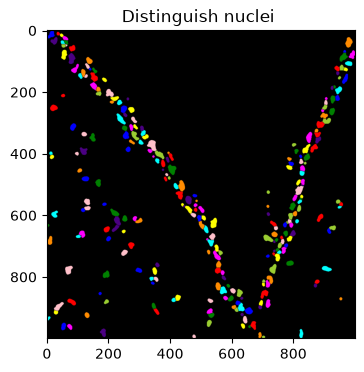

In [15]:
## Distinguish objects

im_distinguish = label2rgb(image_watershed, bg_label = 0, bg_color = 'black')
plt.figure(figsize = (8,4))
plt.imshow(im_distinguish)
plt.title("Distinguish nuclei ")

### 2.7. Draw the boundaries

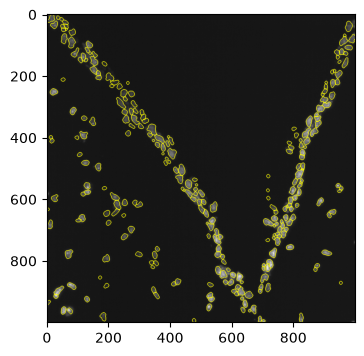

In [16]:
## Draw the boundaries
image_normalize = im / im.max()  # normalize to [0,1]
image_rgb = gray2rgb(image_normalize)
boundary_image = mark_boundaries(image_rgb, image_watershed, mode='thick')
plt.figure(figsize = (8,4))
plt.imshow(boundary_image)
plt.show()

mark boundary funtion: input(float[0,1] => need to normalize the original image beforehand

lab_spots = watershed(-bw_spots_dist, markers = lab_spots, mask =bw_image_cleanup,  watershed_line=True) <br>
mask => water is allowed to expand inside the (bw_image_cleanup) range. - not expanding to background <br>
Misunderstanding: noise in this image is not salt - pepper noise => no need median filter


Most basical step for image preprocessing before counting nuclei is: binary image, watershed. <br>
- The application of filters to clean up image should be considered after each processing step (once binary image has been reviewed, filters can be applied to handle noise/speckle) <br>
- One problem: still have speckle. This is the time to filter nuclei by size.

### 2.8. Filtering

In [17]:
## Filtering by size

props = regionprops_table(image_watershed, properties=['label', 'centroid', 'area'])
df = pd.DataFrame(props)

df_filtered = df[df['area'] > 50].copy()

print(f"Before filtering: {len(df)} nuclei")
print(f"After filtering (area > 50): {len(df_filtered)} nuclei")
df_filtered.to_csv('/Users/chann/Downloads/F1 Systems bio/Project/code/Results/Intermediates/Nuclei counting/nuclei_coordinates_X10_Y2_c01.csv', index=False)


Before filtering: 270 nuclei
After filtering (area > 50): 260 nuclei


Output of region properties: table of nuclei's properties: area, centroid, orientation ... => only nucleis have area > 50 can be accepted.

Simplest way to filter noise in image by size: <br>
- view image through ImageJ => have first glance of nuclei's size
- Try to see size of noise => filter according to this size

## 3. Summerize pipeline for one DAPI image processing

### 3.1. Pipeline for X10_Y2 DAPI image

In [18]:
GAUSSIAN_SIGMA = 1
DOG_LOW_SIGMA = 3
DOG_HIGH_SIGMA = DOG_LOW_SIGMA * 1.6
DISK_RADIUS = 3
H_MAXIMA_THRESHOLD = 0.5
AREA_MIN = 50

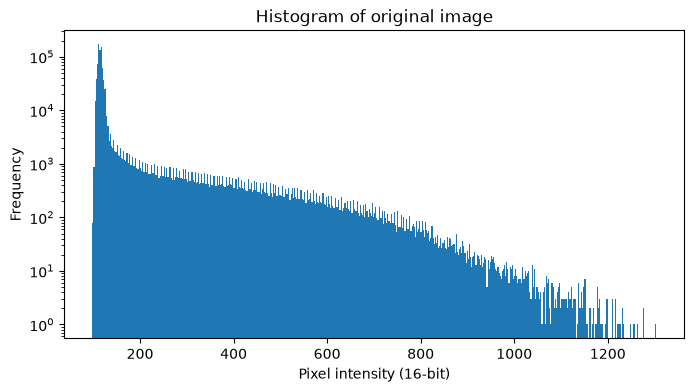

In [19]:
# SUMMERIZE - X10_Y2_c01

# 1. Read original image
path = '/Users/chann/Downloads/F1 Systems bio/Project/code/realistic_data/selected-tiles/out_opt_flow_registered_X10_Y2_c01_DAPI.tif'
im = io.imread(path).astype(np.float32)

#2. Create the histogram => see the overall structure => 1 peaks (unimodal) => triangle thresholding <> two peak => otsu
fig = plt.figure(figsize=(8, 4))
im_hist = plt.hist(im.ravel(), bins=512, range=(im.min(), im.max()),log = True)  #the darkest value and brightest value of pixel
plt.xlabel('Pixel intensity (16-bit)')
plt.ylabel('Frequency')
plt.title('Histogram of original image')
plt.show()

In [20]:
# 3. IMAGE PREPROCESSING

## Apply Gaussian filter
im_gauss = filters.gaussian(im, sigma=1)

## Apply difference of Gaussian filter (1)
im_dog = difference_of_gaussians(im_gauss, low_sigma=3, high_sigma=3 * 1.6)

## Apply thresholding => still have noise and connected nuclei
im_threshold = im_dog > threshold_triangle(im_dog)

## Count the number of nuclei after thresholding: to check number of nuclei before and after morphological opening
labeled_array, num_features = ndimage.label(im_threshold)
print(f"Number of nuclei after thresholding: {num_features}")

## Apply morphological opening:
#still have noise -> use erosion and dilation to solve it. Necessary thing when we'll do watershed. Disk: create the circular structure element <> extrema: min, max
structure_element = disk(3)
im_opened = ndimage.binary_opening(im_threshold, structure=structure_element)
labeled_array, num_features = ndimage.label(im_opened)
print(f'Number of nuclei after morphological opening: {num_features}')

## Apply watershed

## distance transform => calculate the distance from bright spot to the closest black spots.
im_dist = distance_transform_edt(im_opened)
im_dist = np.round(im_dist)

## define the seed (markers): There is a lot of tiny maxima (included noise) -> we use H - maxima to find only the larger maximan => dilate them to resist the too much close distance between seeds.
im_maxima = extrema.h_maxima(im_dist, 0.5)
im_maxima = ndimage.binary_dilation(im_maxima)
im_maxima = im_maxima & im_opened  #set the limitation -> make sure we will not dilate them beyond the boundary of image
lab_seeds, n = ndimage.label(im_maxima)  #count and give them ID => lab_seeds is the result after giving them ID(array) -> n= total number of seeds(integer)
labeled_array, num_features = ndimage.label(im_maxima)
print(f'Number of seeds: {n}')

## apply the watershed
im_water = watershed(-im_dist, markers=lab_seeds, mask=im_opened, watershed_line=True)
print(f'Number of nuclei after watershed:{n}')

## Apply boundaries
im_norm = im / im.max()  # normalize to [0,1]
im_rgb = gray2rgb(im_norm)
im_bound = mark_boundaries(im_rgb, im_water, mode='median')

Number of nuclei after thresholding: 159
Number of nuclei after morphological opening: 161
Number of seeds: 270
Number of nuclei after watershed:270


In [21]:
# 4. Export nuclei coordinates and filtering
props = regionprops_table(im_water, properties=['label', 'centroid', 'area'])
df = pd.DataFrame(props)

## Filtering
df_filtered = df[df['area'] > 50].copy()
print(f"Before filtering: {len(df)} nuclei")
print(f"After filtering (area > 50): {len(df_filtered)} nuclei")

## Save as csv
df_filtered.to_csv('/Users/chann/Downloads/F1 Systems bio/Project/code/Results/Intermediates/Nuclei counting/nuclei_coordinates_X10_Y2_c01_summerize.csv', index=False)

Before filtering: 270 nuclei
After filtering (area > 50): 257 nuclei


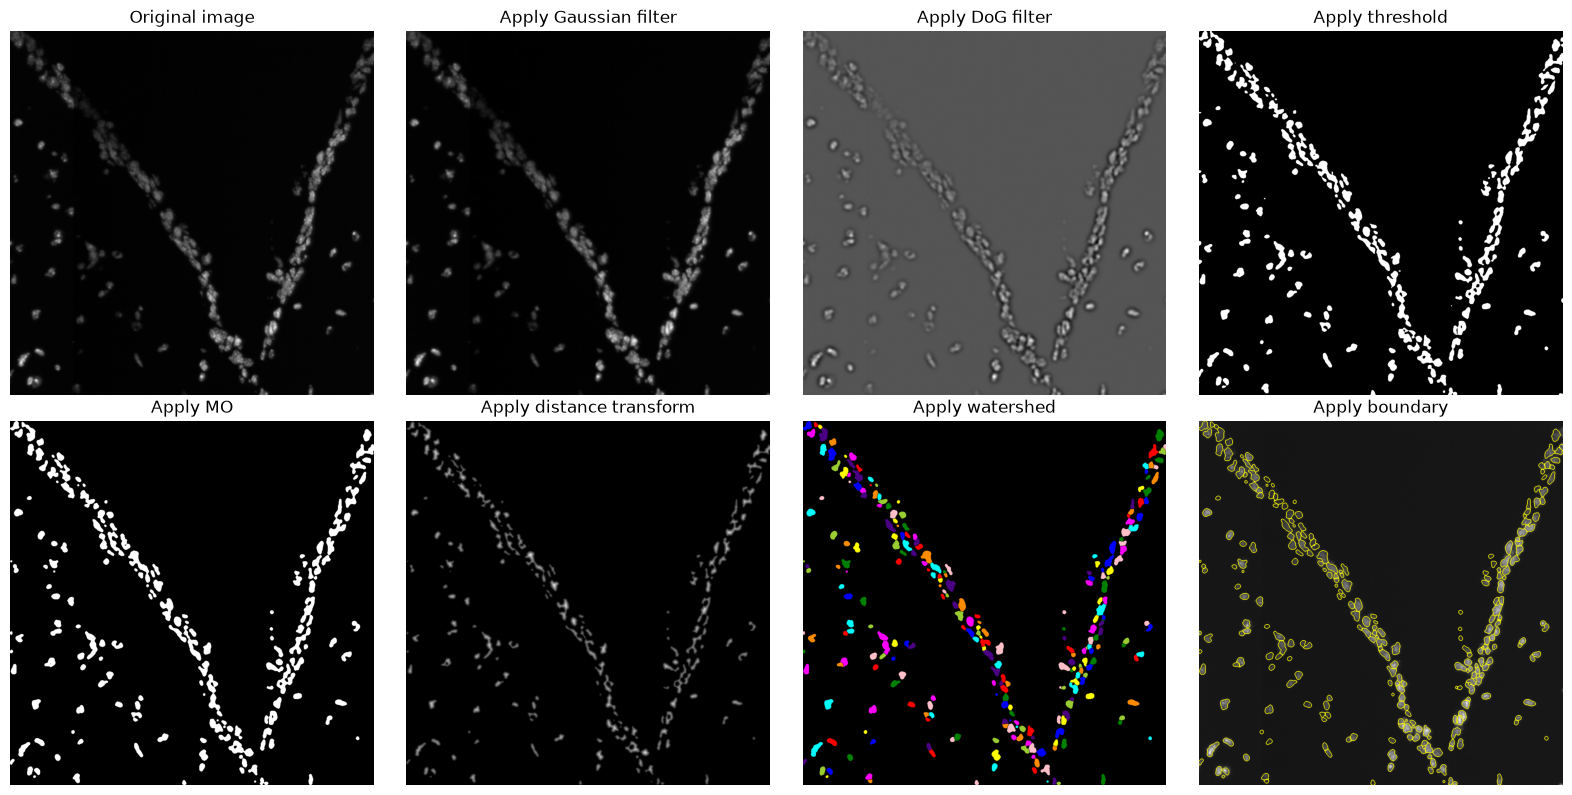

In [22]:
# 5. Plotting

def create_figure(figsize=(8, 4)):
    return plt.figure(figsize=figsize)

def show_image(img, title='', pos=111, cmap='gray'):
    plt.subplot(pos)
    plt.imshow(img, cmap=cmap)
    plt.title(title)
    plt.axis('off')

def glue_fig(name):
    plt.tight_layout()
    plt.savefig(f"{name}.png")
    plt.show()

fig = create_figure(figsize=(16, 8))

show_image(im, title='Original image', pos=241)
show_image(im_gauss, title='Apply Gaussian filter', pos=242, cmap='gray')
show_image(im_dog, title='Apply DoG filter', pos=243, cmap='gray')
show_image(im_threshold, title='Apply threshold', pos=244, cmap='gray')
show_image(im_opened, title='Apply MO', pos=245, cmap='gray')
show_image(im_dist, title='Apply distance transform', pos=246)
show_image(label2rgb(im_water, bg_label=0, bg_color='black'), title='Apply watershed', pos=247)
show_image(im_bound, title='Apply boundary', pos=248, cmap='gray')

glue_fig('fig_overview_workflow')

### 3.2. Apply pipeline for another DAPI image

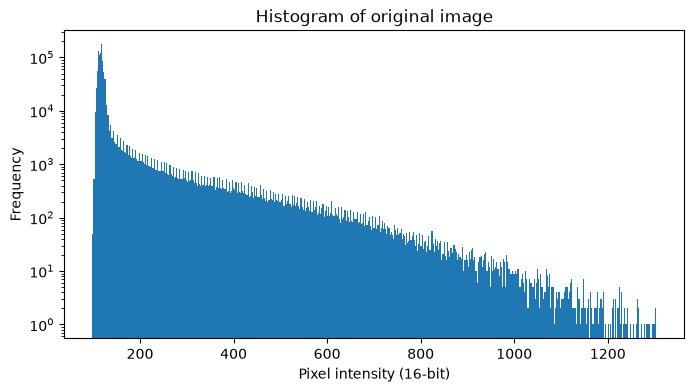

In [23]:
# X10_Y3_c01

# 1. Read original image
path = '/Users/chann/Downloads/F1 Systems bio/Project/code/realistic_data/selected-tiles/out_opt_flow_registered_X10_Y3_c01_DAPI.tif'
im_X10_Y3 = io.imread(path).astype(np.float32)

#2. Create the histogram
fig = plt.figure(figsize=(8, 4))
im_hist = plt.hist(im_X10_Y3.ravel(), bins=512, range=(im.min(), im.max()),
                   log=True)  #the darkest value and brightest value of pixel
plt.xlabel('Pixel intensity (16-bit)')
plt.ylabel('Frequency')
plt.title('Histogram of original image')
plt.show()


In [24]:
# 3. IMAGE PREPROCESSING

## Apply Gaussian filter
im_gauss_1 = filters.gaussian(im_X10_Y3, sigma=1)

## Apply difference of Gaussian filter (1)
im_dog_1 = difference_of_gaussians(im_gauss_1, low_sigma=3, high_sigma=3 * 1.6)

## Apply thresholding => still have noise and connected nuclei
im_threshold_1 = im_dog_1 > threshold_triangle(im_dog_1)

## Count the number of nuclei after thresholding: to check number of nuclei before and after morphological opening
labeled_array, num_features = ndimage.label(im_threshold_1)
print(f"Number of nuclei after thresholding: {num_features}")

## Apply morphological opening:
#still have noise -> use erosion and dilation to solve it. Necessary thing when we'll do watershed. Disk: create the circular structure element <> extrema: min, max
structure_element = disk(3)
im_opened_1 = ndimage.binary_opening(im_threshold_1, structure=structure_element)
labeled_array_1, num_features_1 = ndimage.label(im_opened_1)
print(f'Number of nuclei after morphological opening: {num_features}')

## Apply watershed

## distance transform => calculate the distance from bright spot to the closest black spots.
im_dist_1 = distance_transform_edt(im_opened_1)
im_dist_1 = np.round(im_dist_1)

## define the seed (markers): There is a lot of tiny maxima (included noise) -> we use H - maxima to find only the larger maximan => dilate them to resist the too much close distance between seeds.
im_maxima_1 = extrema.h_maxima(im_dist_1, 0.5)
im_maxima_1 = ndimage.binary_dilation(im_maxima_1)
im_maxima_1 = im_maxima_1 & im_opened_1  #set the limitation -> make sure we will not dilate them beyond the boundary of image
lab_seeds_1, n1 = ndimage.label(
    im_maxima_1)  #count and give them ID => lab_seeds is the result after giving them ID(array) -> n= total number of seeds(integer)
labeled_array_1, num_features_1 = ndimage.label(im_maxima_1)
print(f'Number of seeds: {n1}')

## apply the watershed
im_water_1 = watershed(-im_dist_1, markers=lab_seeds_1, mask=im_opened_1, watershed_line=True)
print(f'Number of nuclei after watershed:{n1}')

## Apply boundaries
im_norm_1 = im_X10_Y3 / im_X10_Y3.max()  # normalize to [0,1]
im_rgb_1 = gray2rgb(im_norm_1)
im_bound_1 = mark_boundaries(im_rgb_1, im_water_1, mode='median')

Number of nuclei after thresholding: 244
Number of nuclei after morphological opening: 244
Number of seeds: 375
Number of nuclei after watershed:375


In [25]:
# 4. Export nuclei coordinates and filtering
props = regionprops_table(im_water_1, properties=['label', 'centroid', 'area'])
df = pd.DataFrame(props)

## Filtering
df_filtered_1 = df[df['area'] > 50].copy()
print(f"Before filtering: {len(df)} nuclei")
print(f"After filtering (area > 50): {len(df_filtered_1)} nuclei")

## Save as csv
# df_filtered.to_csv(
#     '/Users/chann/Downloads/F1 Systems bio/Project/code/Results/Intermediates/Nuclei counting/nuclei_coordinates_X10_Y3_c01_summerize.csv',
#     index=False)

Before filtering: 375 nuclei
After filtering (area > 50): 363 nuclei


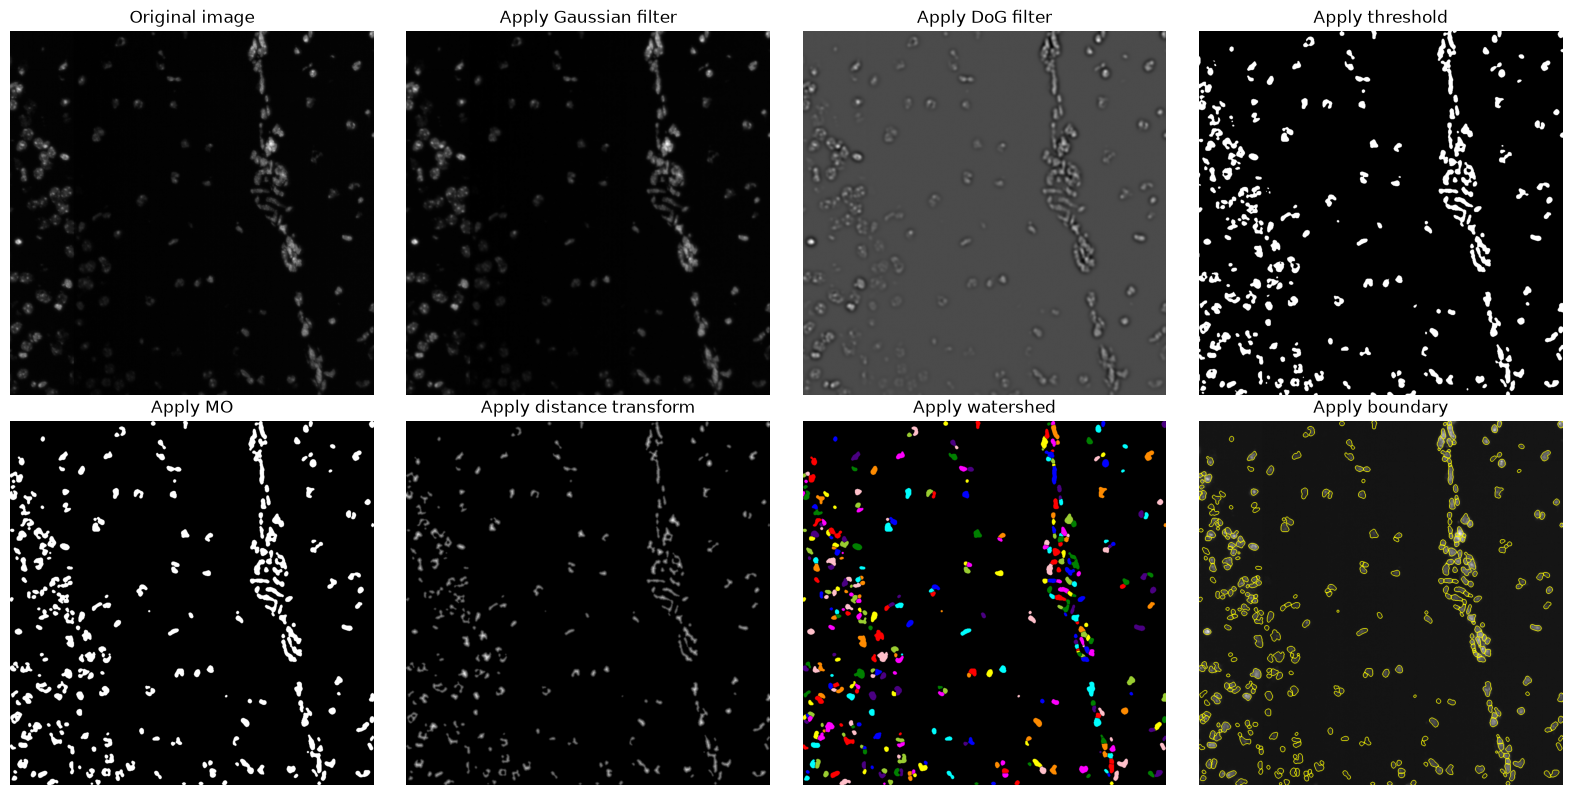

In [26]:
# 5. Plotting

def create_figure(figsize=(8, 4)):
    return plt.figure(figsize=figsize)


def show_image(img, title='', pos=111, cmap='gray'):
    plt.subplot(pos)
    plt.imshow(img, cmap=cmap)
    plt.title(title)
    plt.axis('off')


def glue_fig(name):
    plt.tight_layout()
    plt.savefig(f"{name}.png")
    plt.show()


fig = create_figure(figsize=(16, 8))

show_image(im_X10_Y3, title='Original image', pos=241)
show_image(im_gauss_1, title='Apply Gaussian filter', pos=242, cmap='gray')
show_image(im_dog_1, title='Apply DoG filter', pos=243, cmap='gray')
show_image(im_threshold_1, title='Apply threshold', pos=244, cmap='gray')
show_image(im_opened_1, title='Apply MO', pos=245, cmap='gray')
show_image(im_dist_1, title='Apply distance transform', pos=246)
show_image(label2rgb(im_water_1, bg_label=0, bg_color='black'), title='Apply watershed', pos=247)
show_image(im_bound_1, title='Apply boundary', pos=248, cmap='gray')

glue_fig('fig_overview_workflow')

Normally, nuclei segmentation might be processed on DAPI image from first cycle. However, in this case, the number of nuclei between cycles have massive difference. The results were displayed on below cells

### 3.3. Inconsistent number of nuclei across rounds

#### **Fov: X10_Y2**

In [27]:
# List of all DAPI image per 1 fov

paths = sorted(glob.glob(f'{PATH}/out_opt_flow_registered_X10_Y10_*DAPI.tif'))

# 1 DAPI image
def count_nuclei_one_image(image_path):  #only use in function
    im = io.imread(image_path).astype(np.float32)
    im_gauss = filters.gaussian(im, sigma=GAUSSIAN_SIGMA)
    im_dog = difference_of_gaussians(im_gauss, low_sigma=DOG_LOW_SIGMA, high_sigma=DOG_HIGH_SIGMA)
    im_threshold = im_dog > threshold_triangle(im_dog)
    im_opened = ndimage.binary_opening(im_threshold, structure=disk(DISK_RADIUS))

    im_dist = np.round(distance_transform_edt(im_opened))
    im_maxima = extrema.h_maxima(im_dist, H_MAXIMA_THRESHOLD)
    im_maxima = ndimage.binary_dilation(im_maxima) & im_opened
    lab_seeds, n = ndimage.label(im_maxima)

    im_water = watershed(-im_dist, markers=lab_seeds, mask=im_opened, watershed_line=True)

    # Filtering by size before plotting
    df = pd.DataFrame(regionprops_table(im_water, properties=['label', 'centroid', 'area']))
    df_filter = df[df['area'] > AREA_MIN]
    im_water = np.where(np.isin(im_water,df_filter['label']), im_water,0)

    im_norm = im / im.max()  # normalize to [0,1]
    im_rgb = gray2rgb(im_norm)
    im_bound = mark_boundaries(im_rgb, im_water, mode='median')
    im_name = image_path.split("registered_")[-1]

    return len(df_filter), im, im_gauss, im_dog, im_threshold, im_opened, im_dist, im_water, im_bound, im_name


## Plotting
def show_image(img, title='', pos=111, cmap='gray'):
    plt.subplot(pos)
    plt.imshow(img, cmap=cmap)
    plt.title(title)
    plt.axis('off')


def glue_fig(name):
    plt.tight_layout()
    plt.savefig(f"/Users/chann/Downloads/F1 Systems bio/Project/code/Results/Figures/{name}.png", bbox_inches="tight")
    plt.show()


def im_plot(im, im_gauss, im_dog, im_threshold, im_opened, im_dist, im_water, im_bound, im_name):
    fig = plt.figure(figsize=(16, 8))
    fig.suptitle(im_name)

    show_image(im, title='Original image', pos=241)
    show_image(im_gauss, title='Apply Gaussian filter', pos=242, cmap='gray')
    show_image(im_dog, title='Apply DoG filter', pos=243, cmap='gray')
    show_image(im_threshold, title='Apply threshold', pos=244, cmap='gray')
    show_image(im_opened, title='Apply MO', pos=245, cmap='gray')
    show_image(im_dist, title='Apply distance transform', pos=246)
    show_image(label2rgb(im_water, bg_label=0, bg_color='black'), title='Apply watershed', pos=247)
    show_image(im_bound, title='Apply boundary', pos=248, cmap='gray')

    glue_fig(f'fig_overview_workflow{im_name}')

In [28]:
# 4 DAPI images
def count_nuclei(folder_path):
    nuclei_counts_dict = {}
    paths = sorted(
        glob.glob(folder_path + 'out_opt_flow_registered_X10_Y2_c*_DAPI.tif'))  #list of paths satisfied above condition
    counts = []  # list of number of nuclei per DAPI image
    ims = []  # list of  big images - contain 4 images
    for path in paths:  #
        plot_result = []  #contain 8 images in current round
        len_df, im, im_gauss, im_dog, im_threshold, im_opened, im_dist, im_water, im_bound, im_name = count_nuclei_one_image(path)
        plot_result.append(im)
        plot_result.append(im_gauss)
        plot_result.append(im_dog)
        plot_result.append(im_threshold)
        plot_result.append(im_opened)
        plot_result.append(im_dist)
        plot_result.append(im_water)
        plot_result.append(im_bound)
        plot_result.append(im_name)  #im_name
        ims.append(plot_result)
        counts.append(len_df)
        nuclei_counts_dict[path.split("registered_")[-1]] = len_df
    nuclei_counts_dict['mean'] = np.mean(counts)

    #Plot image
    for (im, im_gauss, im_dog, im_threshold, im_opened, im_dist, im_water, im_bound, im_name) in ims:  #visualization
        im_plot(im, im_gauss, im_dog, im_threshold, im_opened, im_dist, im_water, im_bound, im_name)
    return nuclei_counts_dict, counts

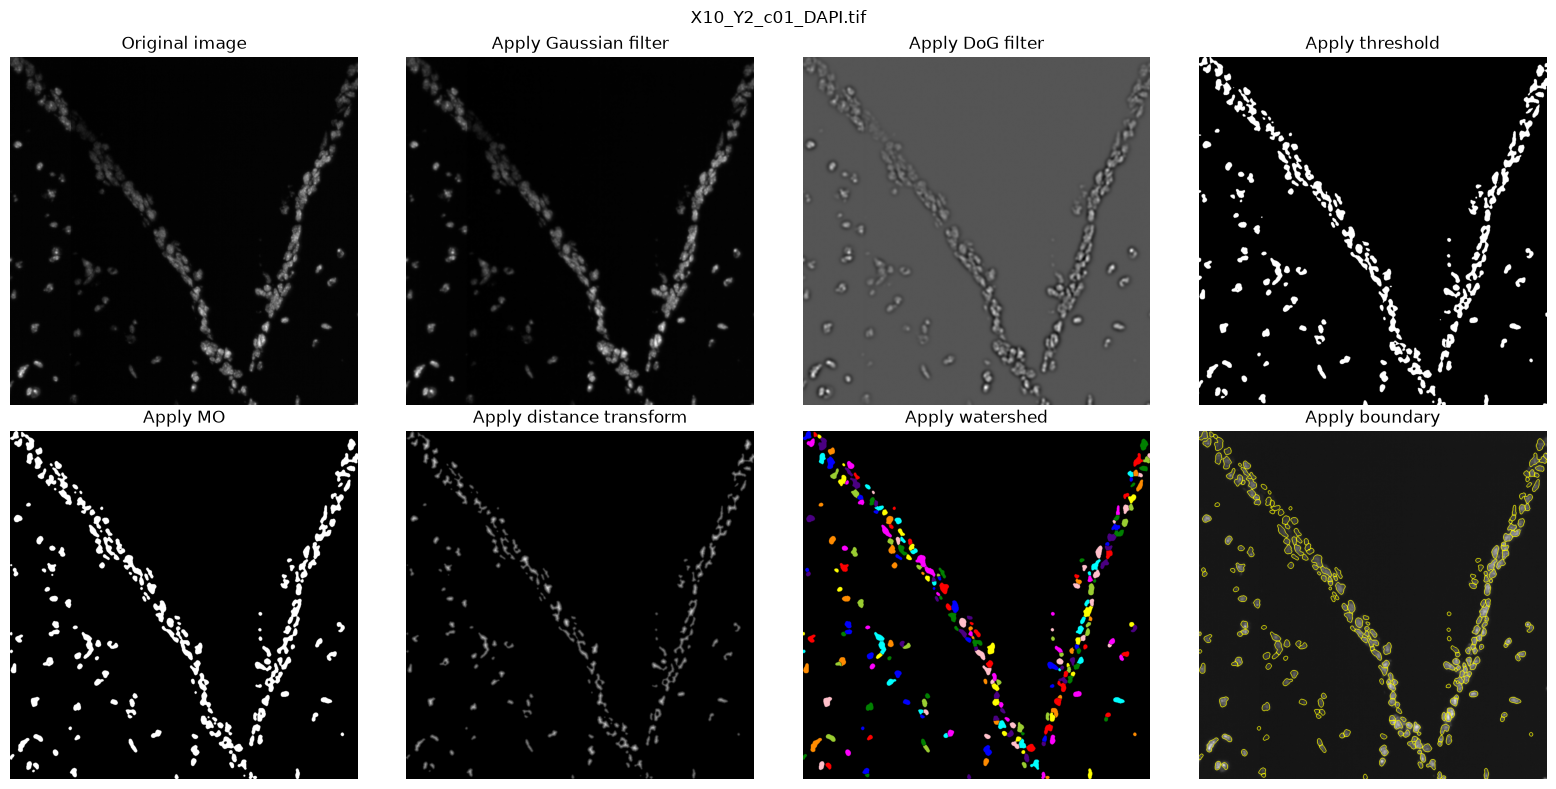

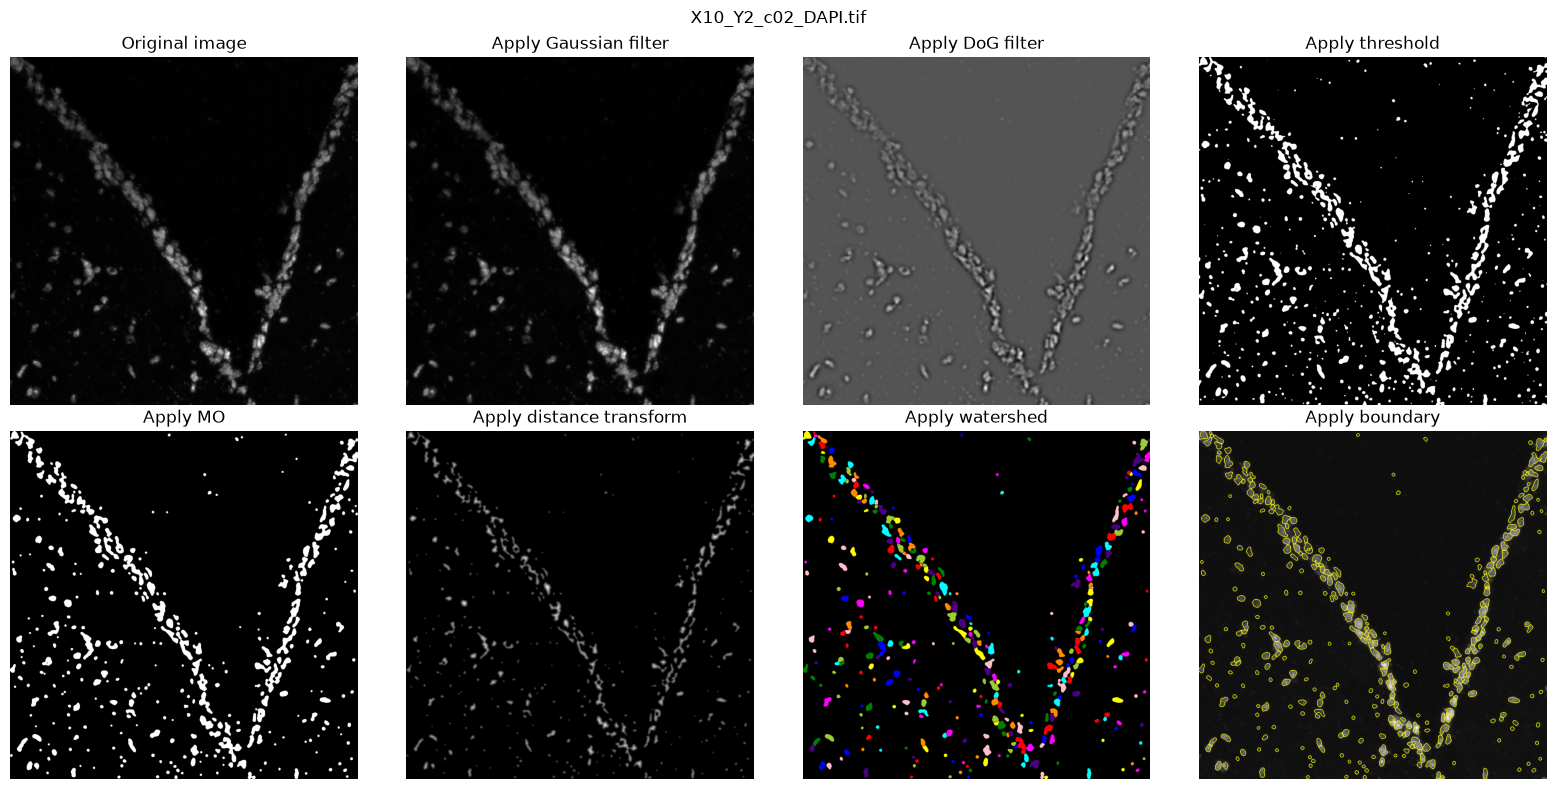

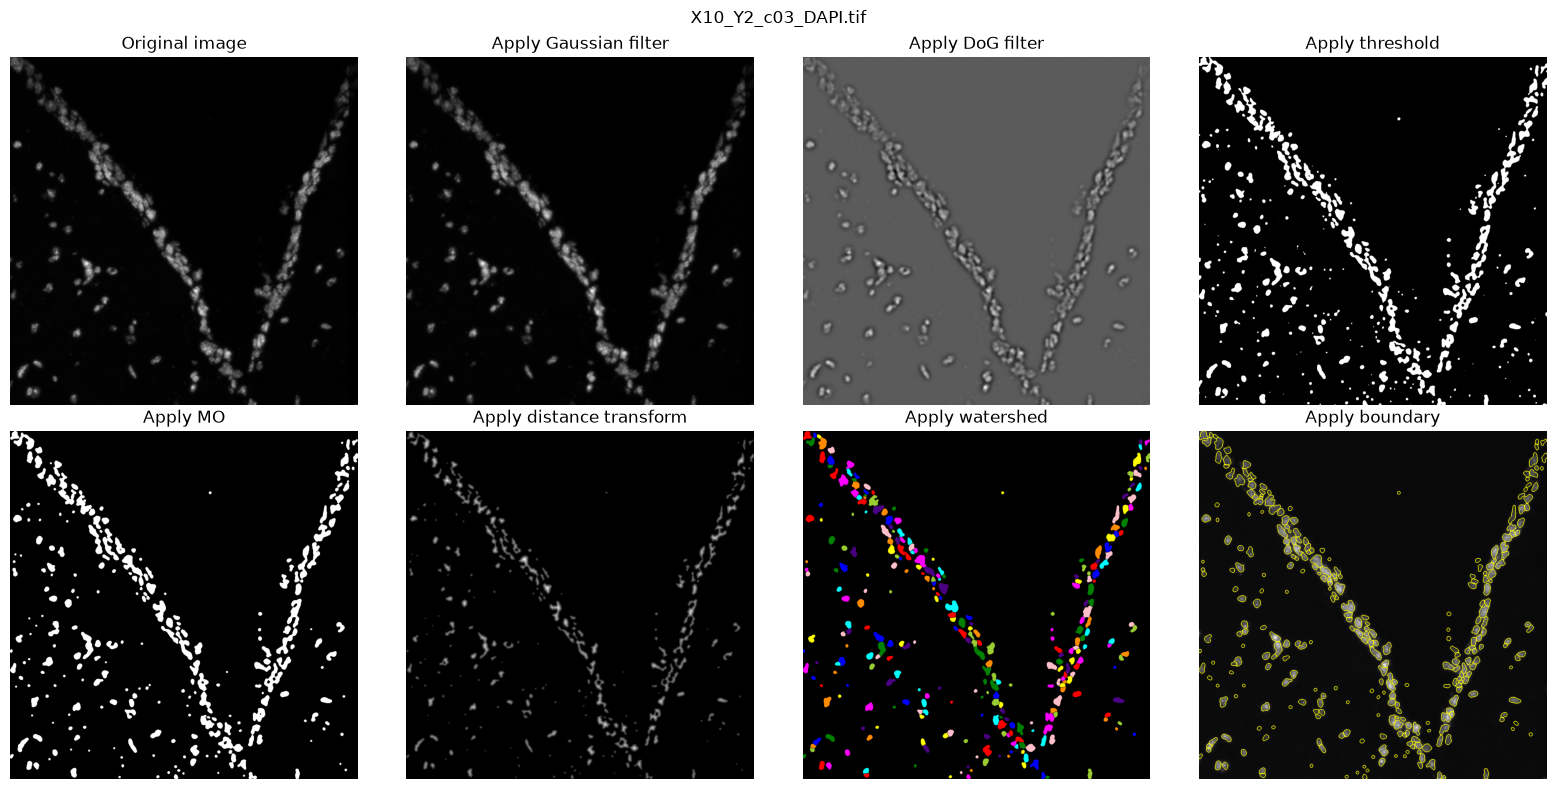

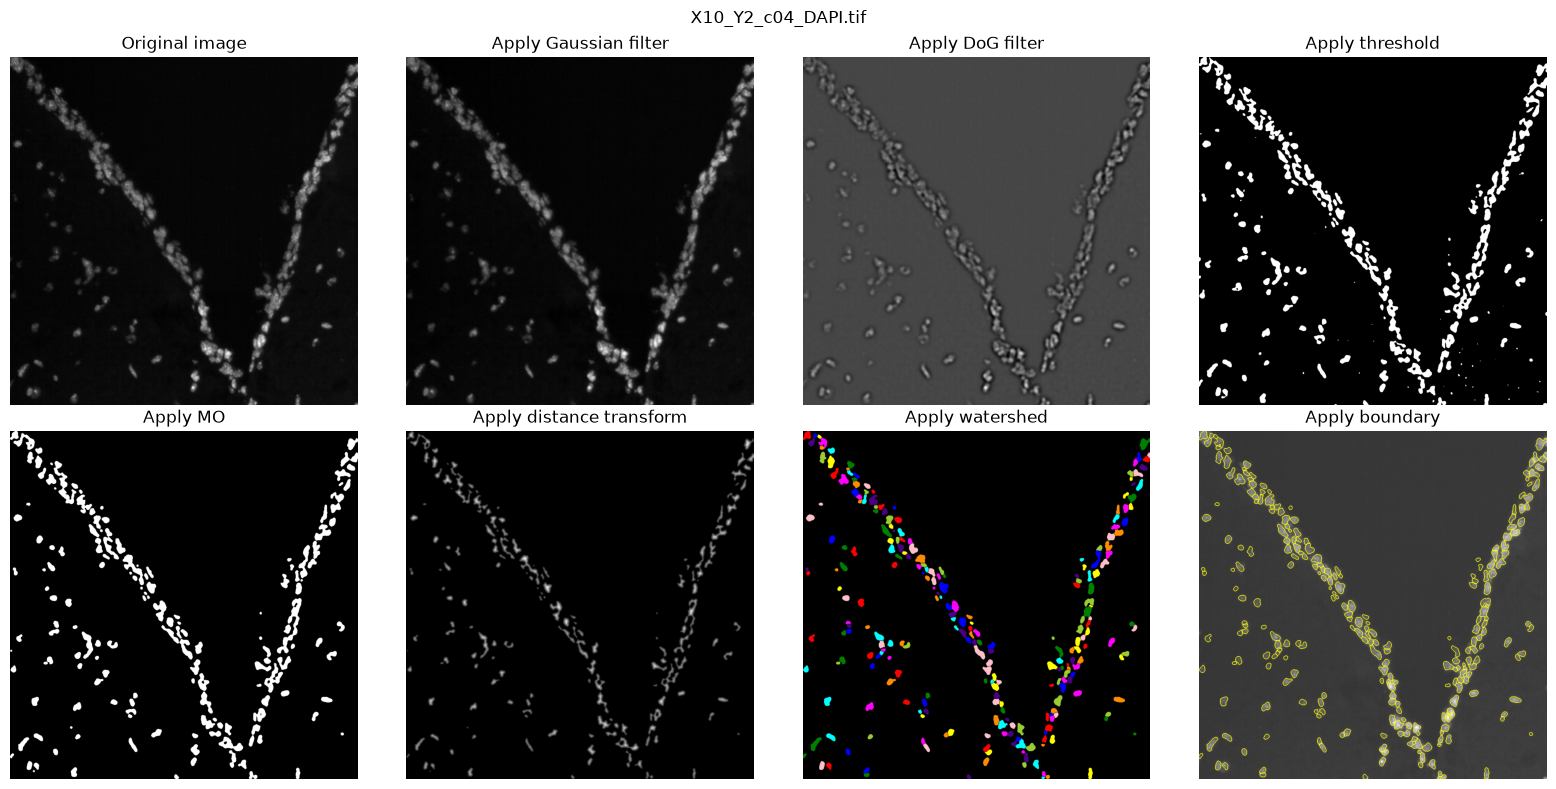

     Name  Round1  Round2  Round3  Round4    Mean
0  X10_Y2     257     353     305     258  293.25


In [29]:
#Number of nuclei
result_nuclei, counts = count_nuclei(PATH)

# Take name of fov from dictionary
image_keys = list(result_nuclei.keys())
image_keys.remove("mean")
fov_name = image_keys[0].split("_c")[
    0]  # from"X10_Y3_c04_DAPI.tif => separate 2 part at 'c' position => take only X10_Y3

row_data = {
    "Name": fov_name,
    "Round1": result_nuclei[image_keys[0]],
    "Round2": result_nuclei[image_keys[1]],
    "Round3": result_nuclei[image_keys[2]],
    "Round4": result_nuclei[image_keys[3]],
    "Mean": result_nuclei[
        "mean"], }  #collect the data => put into dictionary -before putting in csv file => purpuse: key => heading, value -> row1

df_result = pd.DataFrame([row_data])

print(df_result)



Nuclei segmentation pipeline worked with C01 and C04 DAPI image. However, it turned out a problem with remaining images. The variability of number of nuclei could be recorded by measurement and visualization. To prove this point, we could try with some other fovs.

#### **Other fovs**

In [30]:
# 1 DAPI image

def count_nuclei_one_image(image_path):  #only use in function
    im = io.imread(image_path).astype(np.float32)
    im_gauss = filters.gaussian(im, sigma=GAUSSIAN_SIGMA)
    im_dog = difference_of_gaussians(im_gauss, low_sigma=DOG_LOW_SIGMA, high_sigma=DOG_HIGH_SIGMA)
    im_threshold = im_dog > threshold_triangle(im_dog)
    im_opened = ndimage.binary_opening(im_threshold, structure=disk(DISK_RADIUS))

    im_dist = np.round(distance_transform_edt(im_opened))
    im_maxima = extrema.h_maxima(im_dist, H_MAXIMA_THRESHOLD)
    im_maxima = ndimage.binary_dilation(im_maxima) & im_opened
    lab_seeds, n = ndimage.label(im_maxima)

    im_water = watershed(-im_dist, markers=lab_seeds, mask=im_opened, watershed_line=True)

    # Filtering by size before plotting
    df = pd.DataFrame(regionprops_table(im_water, properties=['label', 'centroid', 'area']))
    df_filter = df[df['area'] > AREA_MIN]
    im_water = np.where(np.isin(im_water,df_filter['label']), im_water,0)

    #im_norm = im / im.max()  # normalize to [0,1]
    #im_rgb = gray2rgb(im_norm)
    #im_bound = mark_boundaries(im_rgb, im_water, mode='median')
    im_name = image_path.split("registered_")[-1]

    return len(df_filter), im, im_gauss, im_dog, im_threshold, im_opened, im_dist, im_water, im_name

# 4 DAPI images
def count_nuclei_four_image(folder_path, fov):
    nuclei_counts_dict = {}
    paths = sorted(
        glob.glob(folder_path + f'out_opt_flow_registered_{fov}_c*_DAPI.tif'))  #list of paths satisfied above condition
    counts = []
    for path in paths:
        len_df, im, im_gauss, im_dog, im_threshold, im_opened, im_dist, im_water, im_name = count_nuclei_one_image(
            path)

        counts.append(len_df)
        nuclei_counts_dict[path.split("registered_")[-1].split('_')[2]] = len_df
    nuclei_counts_dict['mean'] = round(np.mean(counts))
    nuclei_counts_dict['name'] = fov

    return nuclei_counts_dict

In [31]:

#Number of nuclei
result_nuclei = [
    count_nuclei_four_image(PATH, 'X11_Y3'),
    count_nuclei_four_image(PATH, 'X20_Y3'),
    count_nuclei_four_image(PATH, 'X10_Y3'),
    count_nuclei_four_image(PATH, 'X10_Y12'),
    count_nuclei_four_image(PATH, 'X10_Y8'),
]

pd.DataFrame(result_nuclei)


,c01,c02,c03,c04,mean,name
0,471,463,469,430,458,X11_Y3
1,453,490,480,456,470,X20_Y3
2,363,410,370,348,373,X10_Y3
3,556,518,549,566,547,X10_Y12
4,470,541,490,466,492,X10_Y8


The above dataframe proved that number of nuclei varies between rounds per fov. Therefore, to count number of nuclei per fov, we should go through 2 steps: <br>
- For each round, nuclei are segmented and counted from that round's DAPI image. <br>
- The final count for the fov is the mean of the counts across all four rounds.

14.1. Develop method on a fov <br>

a. Which channel iss the most promising for nucleus segmentation? <br>
=> DAPI image. Classic fluorescent probe for staining cell nuclei. it shows cell nuclei as bright blue spots against a dark background.

b. Which methods can you use to distinguish between nucleus and the rest? <br>
- Basically: nucleus: foreground <> the rest: background. We use thresholding method to separate them. After applying threshold: nuclei become white spot and the background is black. <br>
- However, because of the noise, we need to apply some filters with suitable index. This is the step we have try many times and give the most suitable one. <br>
- Applied filters: Gaussian(sigma = 1), difference of gaussian filter(sigma1 = 3, sigma2 = sigma1*1.6), morphological opening(radius of disk = 3) (reference: based on Robert Hasse) <br>

c. How can you divide the nuclei into separate instances? <br>
- I used watershed (module: skimage.segmentation - package: skimage) (tried 2 ways to find markers). Finally, I choose h - maxima to do this. <br>
- Breaking algorithm down into steps helps me better visualize the progress.

d. Which problems occur, how can they be addressed? <br>
- Understand how the filters work and choose them reasonably + choose suitable index for them => read documentation + study Robert Hasse study course on Youtube <br>
- Variablity of number of nuclei between rounds per fov => nuclei segmentation on all of DAPI images per fov and take the mean.
- Get used to with pandas, dataframe => practice <br>
- Misunderstanding the type of noise (salt - pepper noise and shot noise/read noise) => watch video to identify <br>
- Forgot syntax !!! => Practice, Practice, Practice.